# 구위(Stuff) 지표 파이프라인 — 베이스라인 전체 실행 (2025 정규시즌)

tjStuff+ 처럼 **타석 정보 없이 투구 물리량만으로 구위를 평가**하는 지표.

| 단계 | 내용 | 모델/방법 |
|---|---|---|
| 1 | 타구 정보(타구방향·타구속도·발사각·공격각도) → 타구결과(0 아웃 / 1 1루타 / 2 2·3루타 / 3 홈런) | RandomForest 다중분류 |
| 2 | 예측확률 기대값(0~3) → Gamma 적합 → Beta 변환 → **타구질 score (0~1)** | Gamma-Beta calibration |
| 3 | 투구 정보 → 타구질 score (헛스윙·루킹삼진 = 0) | **LGBM 베이스라인** (추후 커스텀 모델로 교체) |
| 4 | 3단계 예측값 → **구위 score (20~80, 중앙값 50, 대칭)** | ECDF → 정규분위수 |

- 데이터 : `games_25_final.pkl` 의 정규시즌(`game_type == 'R'`)만 사용
- 검증셋 : 정규시즌 마지막 1개월 / 학습셋 : 그 이전
- 공통 함수는 `stuff_pipeline.py` 에 정의

In [1]:
import os, warnings, joblib
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count()))    # Windows 에서 loky 코어 탐색 경고 방지
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (log_loss, accuracy_score, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.calibration import calibration_curve

import stuff_pipeline as sp

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
SEED = sp.SEED

## 0. 데이터 로드 및 학습/검증 분할

In [2]:
df = sp.load_regular_season('games_25_final.pkl')
train_df, valid_df, valid_start = sp.split_last_month(df, months=1)
print(f'정규시즌 : {df.game_date.min().date()} ~ {df.game_date.max().date()}  ({len(df):,} pitches)')
print(f'학습셋   : ~ {(valid_start - pd.Timedelta(days=1)).date()}  ({len(train_df):,})')
print(f'검증셋   : {valid_start.date()} ~  ({len(valid_df):,})')

# 학습셋 내부 홀드아웃 (튜닝/early stopping 용, 학습셋 마지막 2주) -> 검증셋은 최종 평가에만 사용
inner_start = valid_start - pd.Timedelta(days=14)

정규시즌 : 2025-03-18 ~ 2025-09-28  (712,528 pitches)
학습셋   : ~ 2025-08-28  (588,716)
검증셋   : 2025-08-29 ~  (123,812)


## 1. 타구결과 예측 모델 (다중분류)
- 표본 : 인플레이 타구(`type == 'X'`) — 파울 제외, 파울플라이아웃 포함 / `truncated_pa`, `catcher_interf` 제외
- 실책(`field_error`)은 타구질 관점에서 아웃(0)으로 처리

In [3]:
X1_tr, y1_tr = sp.build_hit_dataset(train_df)
X1_va, y1_va = sp.build_hit_dataset(valid_df)
print('train', X1_tr.shape, ' valid', X1_va.shape)
print(pd.concat([y1_tr.value_counts(normalize=True).rename('train'),
                 y1_va.value_counts(normalize=True).rename('valid')], axis=1).rename(index=sp.HIT_LABELS).round(4))
print('\n결측률\n', X1_tr.isna().mean().round(4))

train (103339, 4)  valid (21100, 4)
                train   valid
events                       
Out            0.6783  0.6764
Single         0.2093  0.2098
Double/Triple  0.0673  0.0670
HomeRun        0.0451  0.0468

결측률
 spray_angle     0.0004
launch_speed    0.0000
launch_angle    0.0000
attack_angle    0.0505
dtype: float64


### 1-1. 하이퍼파라미터 튜닝 (학습셋 내부 시계열 홀드아웃, log loss 기준)

In [4]:
inner = train_df.loc[X1_tr.index, 'game_date'] >= inner_start
Xa, ya, Xb, yb = X1_tr[~inner], y1_tr[~inner], X1_tr[inner], y1_tr[inner]

rows = []
for max_depth in [8, 12, 16]:
    for min_leaf in [25, 50, 100]:
        rf = RandomForestClassifier(n_estimators=150, max_depth=max_depth, min_samples_leaf=min_leaf,
                                    n_jobs=-1, random_state=SEED).fit(Xa, ya)
        rows.append({'max_depth': max_depth, 'min_samples_leaf': min_leaf,
                     'logloss': log_loss(yb, rf.predict_proba(Xb), labels=[0, 1, 2, 3])})
rf_tune = pd.DataFrame(rows).sort_values('logloss')
display(rf_tune)
best_rf = rf_tune.iloc[0][['max_depth', 'min_samples_leaf']].astype(int).to_dict()
best_rf

,max_depth,min_samples_leaf,logloss
6,16,25,0.463414
7,16,50,0.472458
3,12,25,0.474032
4,12,50,0.481156
8,16,100,0.487024
5,12,100,0.492120
0,8,25,0.520019
1,8,50,0.522017
2,8,100,0.525887


{'max_depth': 16, 'min_samples_leaf': 25}

### 1-2. 최종 학습 및 검증셋 평가 (DecisionTree 비교)

In [5]:
hit_model = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, **best_rf).fit(X1_tr, y1_tr)
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=100, random_state=SEED).fit(X1_tr, y1_tr)

prior = np.tile(y1_tr.value_counts(normalize=True).sort_index().values, (len(y1_va), 1))
P1_va = hit_model.predict_proba(X1_va)
summary = pd.DataFrame({
    'logloss': [log_loss(y1_va, prior), log_loss(y1_va, dt.predict_proba(X1_va)), log_loss(y1_va, P1_va)],
    'accuracy': [accuracy_score(y1_va, np.zeros(len(y1_va))), accuracy_score(y1_va, dt.predict(X1_va)),
                 accuracy_score(y1_va, P1_va.argmax(1))],
}, index=['Prior (baseline)', 'DecisionTree', 'RandomForest'])
display(summary.round(4))

cm = pd.DataFrame(confusion_matrix(y1_va, P1_va.argmax(1)),
                  index=[f'true_{v}' for v in sp.HIT_LABELS.values()],
                  columns=[f'pred_{v}' for v in sp.HIT_LABELS.values()])
display(cm)

,logloss,accuracy
Prior (baseline),0.9164,0.6764
DecisionTree,0.5316,0.7901
RandomForest,0.4490,0.8165


,pred_Out,pred_Single,pred_Double/Triple,pred_HomeRun
true_Out,13164,890,134,85
true_Single,1641,2691,88,6
true_Double/Triple,533,199,591,91
true_HomeRun,159,1,44,783


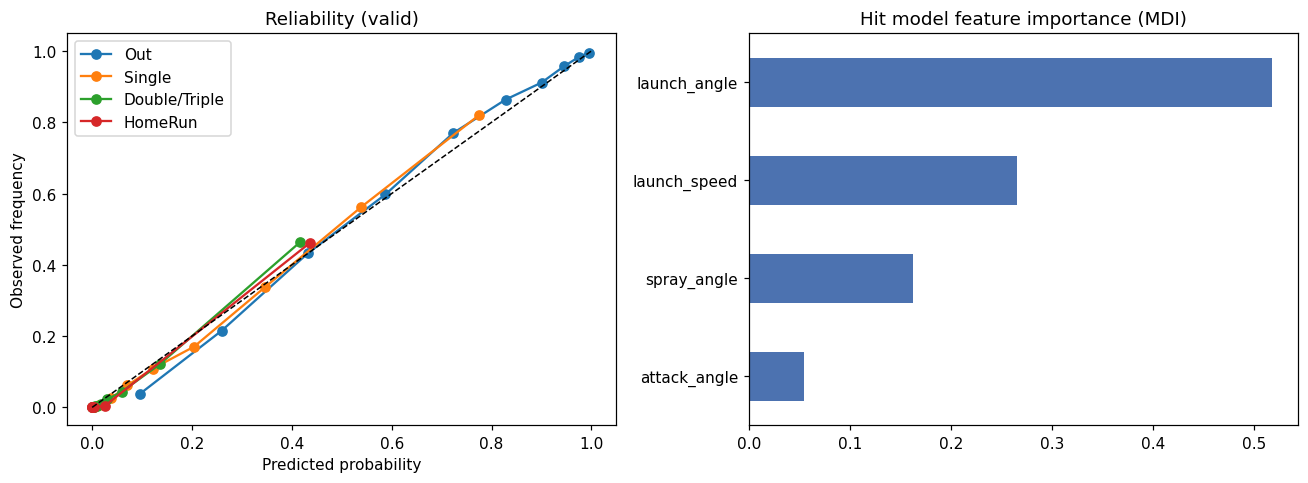

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for k, name in sp.HIT_LABELS.items():
    frac, mean_pred = calibration_curve((y1_va == k).astype(int), P1_va[:, k], n_bins=10, strategy='quantile')
    axes[0].plot(mean_pred, frac, marker='o', label=name)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(title='Reliability (valid)', xlabel='Predicted probability', ylabel='Observed frequency')
axes[0].legend()

imp = pd.Series(hit_model.feature_importances_, index=sp.HIT_FEATURES).sort_values()
imp.plot.barh(ax=axes[1], color='#4C72B0')
axes[1].set(title='Hit model feature importance (MDI)')
plt.tight_layout(); plt.savefig('outputs/stage1_hit_model.png'); plt.show()

### 1-3. 학습셋 타구의 Out-of-Fold 예측
학습셋 타구에 대해 in-sample 예측을 그대로 쓰면 과적합된 확률이 3단계 y 로 들어가므로, 5-fold OOF 예측을 사용한다.

In [7]:
P1_tr = cross_val_predict(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED, **best_rf), X1_tr, y1_tr,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), method='predict_proba')
print('train OOF logloss :', round(log_loss(y1_tr, P1_tr), 4))

train OOF logloss : 0.4581


## 2. 타구질 score (0~1) : Gamma → Beta calibration
- 기대값 `E = P1 + 2·P2 + 3·P3` (0~3)
- 학습셋 E 에 Gamma 분포 적합 → `u = GammaCDF(E)` → `score = BetaPPF(u)` (Beta 모수는 E/3 적률법 추정)
- 변환 모수는 학습셋에서만 추정하고 검증셋에 그대로 적용

In [8]:
E_tr, E_va = sp.expected_value(P1_tr), sp.expected_value(P1_va)
calib = sp.GammaBetaCalibrator().fit(E_tr)
print(calib)

hit_score = pd.concat([pd.Series(calib.transform(E_tr), index=X1_tr.index),
                       pd.Series(calib.transform(E_va), index=X1_va.index)])
print(f'score range : {hit_score.min():.4f} ~ {hit_score.max():.4f}')
print('\n실제 결과별 평균 타구질 score (valid)')
display(pd.DataFrame({'y': y1_va.map(sp.HIT_LABELS), 'score': hit_score[X1_va.index]})
        .groupby('y')['score'].describe().round(3))

GammaBetaCalibrator(gamma_a=0.657, gamma_scale=0.728, beta_a=0.423, beta_b=2.228)
score range : 0.0000 ~ 0.8181

실제 결과별 평균 타구질 score (valid)


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
Double/Triple,1414.0,0.415,0.182,0.000,0.293,0.432,0.571,0.810
HomeRun,987.0,0.677,0.160,0.009,0.618,0.742,0.791,0.818
Out,14273.0,0.079,0.113,0.000,0.005,0.027,0.110,0.746
Single,4426.0,0.240,0.120,0.000,0.152,0.254,0.339,0.809


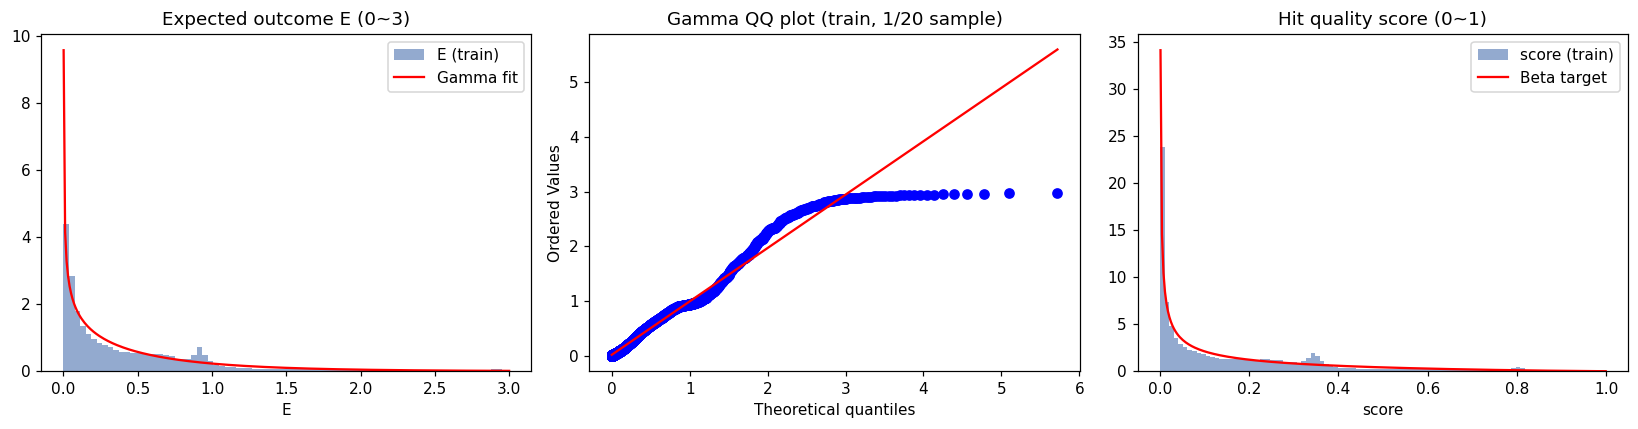

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
grid = np.linspace(1e-3, 3, 300)
axes[0].hist(E_tr, bins=80, density=True, alpha=.6, color='#4C72B0', label='E (train)')
axes[0].plot(grid, stats.gamma.pdf(grid, calib.gamma_a, scale=calib.gamma_scale), 'r', label='Gamma fit')
axes[0].set(title='Expected outcome E (0~3)', xlabel='E'); axes[0].legend()

stats.probplot(E_tr[::20], dist=stats.gamma, sparams=(calib.gamma_a, 0, calib.gamma_scale), plot=axes[1])
axes[1].set_title('Gamma QQ plot (train, 1/20 sample)')

axes[2].hist(hit_score[X1_tr.index], bins=80, density=True, alpha=.6, color='#4C72B0', label='score (train)')
g = np.linspace(1e-3, 1 - 1e-3, 300)
axes[2].plot(g, stats.beta.pdf(g, calib.beta_a, calib.beta_b), 'r', label='Beta target')
axes[2].set(title='Hit quality score (0~1)', xlabel='score'); axes[2].legend()
plt.tight_layout(); plt.savefig('outputs/stage2_hit_score.png'); plt.show()

## 3. 구위 모델 : 투구 정보 → 타구질 score (LGBM 베이스라인)
- 표본 : 인플레이 타구 + 헛스윙(`swinging_strike`, `swinging_strike_blocked`) + 루킹 삼진 → 후자 두 경우 y = 0
- 설명변수 (로케이션 제외, tjStuff+ 방식) : 구속, 무브먼트, 릴리스 포인트, 익스텐션, 회전수·회전축, 팔각도, 초기 속도/가속도, 구종, 투구손, 주 패스트볼 대비 차이
- 좌투는 수평 성분을 부호 반전해 우투 기준으로 정규화
- **추후 사용자 커스텀 모델로 교체 예정** → `sp.fit_stuff_model` 자리만 바꾸면 이후 단계는 그대로 동작

In [10]:
feat = sp.add_stuff_features(df)    # 전체 정규시즌 투구에 물리량 피처 생성 (결과 정보 미사용)
X3, y3 = sp.build_stuff_dataset(feat, hit_score)
is_va3 = feat.loc[X3.index, 'game_date'] >= valid_start
is_es3 = (feat.loc[X3.index, 'game_date'] >= inner_start) & ~is_va3

X3_tr, y3_tr = X3[~is_va3 & ~is_es3], y3[~is_va3 & ~is_es3]
X3_es, y3_es = X3[is_es3], y3[is_es3]
X3_va, y3_va = X3[is_va3], y3[is_va3]
print('train', X3_tr.shape, ' inner-holdout', X3_es.shape, ' valid', X3_va.shape)
print('y = 0 (헛스윙/루킹삼진) 비율 :', round((y3 == 0).mean(), 4))
X3.describe().T.round(2)

train (157966, 20)  inner-holdout (16647, 20)  valid (36927, 20)
y = 0 (헛스윙/루킹삼진) 비율 : 0.4132


,count,mean,std,min,25%,50%,75%,max
release_speed,211539.0,89.17,6.07,31.5,85.0,89.5,94.1,104.1
pfx_x,211496.0,-3.96,10.2,-28.56,-12.84,-5.76,3.96,30.48
pfx_z,211539.0,6.43,8.5,-22.2,0.96,6.48,13.68,30.6
release_pos_x,211539.0,-1.93,0.74,-5.14,-2.4,-1.94,-1.44,1.01
release_pos_z,211539.0,5.77,0.51,1.07,5.5,5.82,6.08,8.25
release_extension,211518.0,6.44,0.45,3.0,6.2,6.4,6.7,9.5
release_spin_rate,210996.0,2268.42,382.16,13.0,2123.0,2313.0,2490.0,3584.0
spin_axis,210995.0,175.22,74.05,0.0,111.0,209.0,227.0,360.0
arm_angle,211170.0,37.69,12.9,-67.4,30.3,38.5,46.2,87.1
vx0,211539.0,5.58,2.59,-5.56,3.82,5.59,7.33,17.28


In [11]:
stuff_model = sp.fit_stuff_model(X3_tr, y3_tr, X3_es, y3_es, n_iter=12)
display(stuff_model.tuning_results_.head())

[01] rmse=0.16182 iter=1140 {'num_leaves': 15, 'min_child_samples': 400, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'subsample': 0.7, 'reg_lambda': 5.0}
[02] rmse=0.16206 iter=2995 {'num_leaves': 15, 'min_child_samples': 200, 'learning_rate': 0.02, 'colsample_bytree': 0.6, 'subsample': 0.9, 'reg_lambda': 5.0}
[03] rmse=0.16179 iter=336 {'num_leaves': 63, 'min_child_samples': 400, 'learning_rate': 0.05, 'colsample_bytree': 1.0, 'subsample': 0.9, 'reg_lambda': 0.0}
[04] rmse=0.16218 iter=291 {'num_leaves': 127, 'min_child_samples': 100, 'learning_rate': 0.05, 'colsample_bytree': 0.8, 'subsample': 0.7, 'reg_lambda': 5.0}
[05] rmse=0.16174 iter=794 {'num_leaves': 127, 'min_child_samples': 200, 'learning_rate': 0.02, 'colsample_bytree': 1.0, 'subsample': 0.9, 'reg_lambda': 1.0}
[06] rmse=0.16203 iter=1644 {'num_leaves': 31, 'min_child_samples': 50, 'learning_rate': 0.02, 'colsample_bytree': 0.8, 'subsample': 0.9, 'reg_lambda': 0.0}
[07] rmse=0.16164 iter=506 {'num_leaves': 127, 'min_ch

,rmse,best_iter,num_leaves,min_child_samples,learning_rate,colsample_bytree,subsample,reg_lambda
6,0.161644,506,127,400,0.02,0.8,0.7,5.0
10,0.161713,540,127,200,0.02,1.0,0.7,0.0
7,0.161716,1063,63,100,0.02,1.0,0.7,5.0
4,0.161737,794,127,200,0.02,1.0,0.9,1.0
2,0.161788,336,63,400,0.05,1.0,0.9,0.0


In [12]:
def reg_metrics(y, p):
    return {'RMSE': np.sqrt(mean_squared_error(y, p)), 'MAE': mean_absolute_error(y, p), 'R2': r2_score(y, p)}

pred3_va = stuff_model.predict(X3_va)
metrics3 = pd.DataFrame({
    'Mean baseline': reg_metrics(y3_va, np.full(len(y3_va), pd.concat([y3_tr, y3_es]).mean())),
    'LGBM': reg_metrics(y3_va, pred3_va),
}).T
display(metrics3.round(5))

# 예측값 분위별 실제 타구질 (순위 설명력 확인)
dec = pd.qcut(pred3_va, 10, labels=False)
display(pd.DataFrame({'pred': pred3_va, 'actual': y3_va.values, 'decile': dec})
        .groupby('decile')[['pred', 'actual']].mean().round(4).T)

,RMSE,MAE,R2
Mean baseline,0.16750,0.12235,-0.00011
LGBM,0.16093,0.11223,0.07681


decile,0,1,2,3,4,5,6,7,8,9
pred,0.0086,0.0419,0.0621,0.0781,0.0916,0.1034,0.1149,0.1268,0.1406,0.1653
actual,0.0130,0.0384,0.0570,0.0716,0.0862,0.1028,0.1162,0.1355,0.1484,0.1637


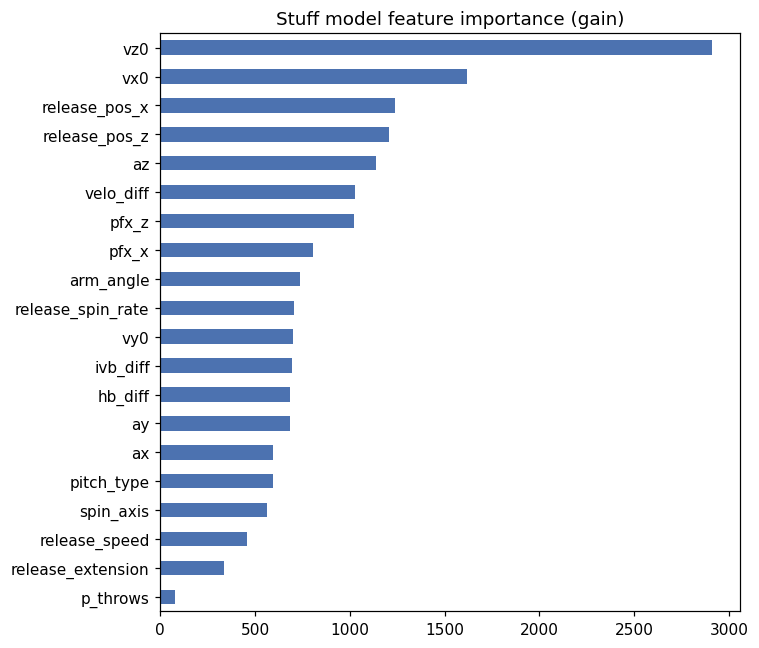

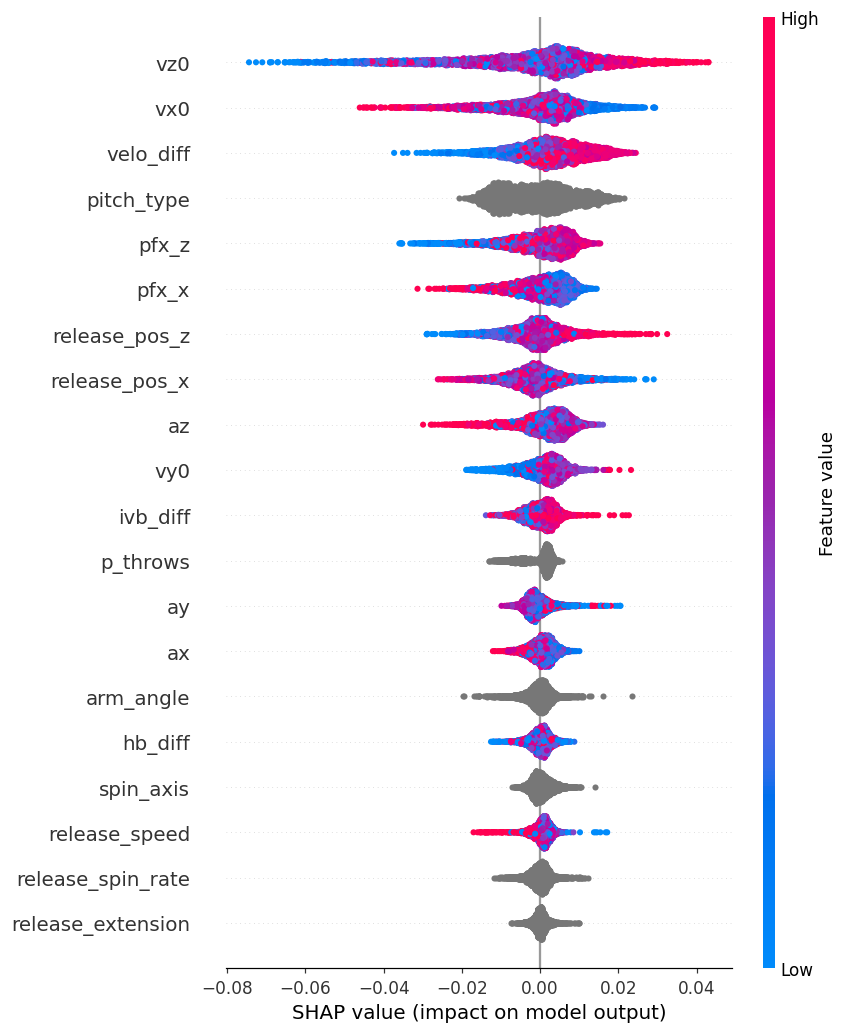

In [13]:
import shap
fig, ax = plt.subplots(figsize=(7, 6))
pd.Series(stuff_model.booster_.feature_importance('gain'), index=sp.STUFF_FEATURES).sort_values() \
  .plot.barh(ax=ax, color='#4C72B0')
ax.set(title='Stuff model feature importance (gain)')
plt.tight_layout(); plt.savefig('outputs/stage3_importance.png'); plt.show()

X_shap = X3_va.sample(5000, random_state=SEED)
shap_values = shap.TreeExplainer(stuff_model).shap_values(X_shap)
shap.summary_plot(shap_values, X_shap, show=False)
plt.tight_layout(); plt.savefig('outputs/stage3_shap.png'); plt.show()

## 4. 최종 구위 score (20~80)
- 모든 정규시즌 투구에 3단계 모델을 적용 (구위는 결과와 무관하게 모든 투구에 정의됨)
- raw = −예측 타구질 → 학습기간 투구의 ECDF → 표준정규 분위수 z → `50 + 10z`, [20, 80] clip
- 학습기간 기준 중앙값 50, 50 을 중심으로 대칭 / 검증기간은 학습기간 분포로 변환

train : median=50.00, mean=50.00, skew=-0.000, min=20.0, max=80.0
valid : median=50.16, mean=50.29, skew=0.036


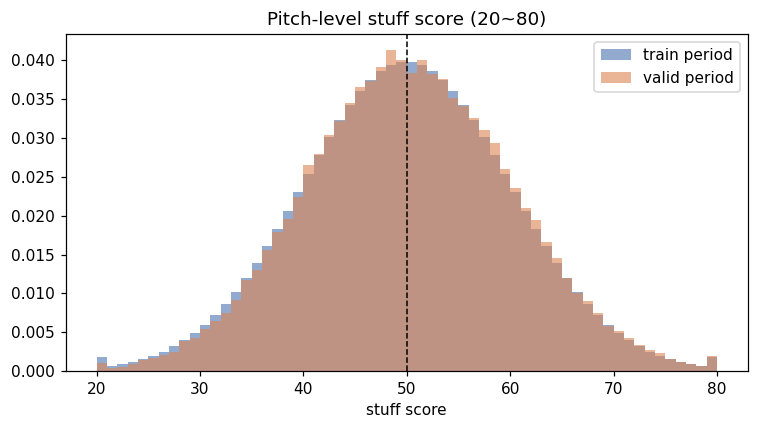

,count,mean,median
pitch_type,,,
FO,540,57.09,58.95
FS,23580,54.15,54.53
CH,73088,52.98,53.55
SL,104854,52.43,52.28
KC,12016,52.24,51.80
ST,49997,52.21,51.85
SV,3524,51.54,50.59
CU,49675,50.83,50.37
SC,7,49.28,44.78


In [14]:
feat['pred_hit_quality'] = stuff_model.predict(feat[sp.STUFF_FEATURES])
is_train_pitch = feat['game_date'] < valid_start
scaler = sp.StuffScaler().fit(feat.loc[is_train_pitch, 'pred_hit_quality'])
feat['stuff_score'] = scaler.transform(feat['pred_hit_quality'])

s_tr = feat.loc[is_train_pitch, 'stuff_score']
print(f'train : median={s_tr.median():.2f}, mean={s_tr.mean():.2f}, skew={stats.skew(s_tr):.3f}, '
      f'min={s_tr.min():.1f}, max={s_tr.max():.1f}')
s_va = feat.loc[~is_train_pitch, 'stuff_score']
print(f'valid : median={s_va.median():.2f}, mean={s_va.mean():.2f}, skew={stats.skew(s_va):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(s_tr, bins=60, alpha=.6, density=True, label='train period', color='#4C72B0')
ax.hist(s_va, bins=60, alpha=.6, density=True, label='valid period', color='#DD8452')
ax.axvline(50, color='k', ls='--', lw=1)
ax.set(title='Pitch-level stuff score (20~80)', xlabel='stuff score'); ax.legend()
plt.tight_layout(); plt.savefig('outputs/stage4_stuff_score.png'); plt.show()

display(feat.groupby('pitch_type', observed=True)['stuff_score'].agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False).round(2))

### 4-1. 리더보드 및 타당성 체크 (검증기간)

In [15]:
va = feat[~is_train_pitch].copy()
va['swing'] = va['description'].isin(['swinging_strike', 'swinging_strike_blocked', 'foul', 'foul_tip',
                                      'hit_into_play', 'foul_bunt', 'missed_bunt'])
va['whiff'] = va['description'].isin(sp.WHIFF_DESC)
va['xwoba_con'] = va['estimated_woba_using_speedangle'].where(va['type'] == 'X')

pp = (va.groupby(['player_name', 'pitch_type'], observed=True)
        .agg(pitches=('stuff_score', 'size'), stuff=('stuff_score', 'mean'), velo=('release_speed', 'mean'),
             swings=('swing', 'sum'), whiffs=('whiff', 'sum'), xwoba_con=('xwoba_con', 'mean'))
        .reset_index())
pp['whiff_pct'] = pp['whiffs'] / pp['swings']
pp_q = pp[pp['pitches'] >= 100]

print('투수x구종 (100구 이상) :', len(pp_q))
print('corr(stuff, whiff%)    :', round(pp_q[['stuff', 'whiff_pct']].corr(method='spearman').iloc[0, 1], 3))
print('corr(stuff, xwOBAcon)  :', round(pp_q[['stuff', 'xwoba_con']].corr(method='spearman').iloc[0, 1], 3))
display(pp_q.sort_values('stuff', ascending=False).head(15).round(3))

투수x구종 (100구 이상) : 341
corr(stuff, whiff%)    : 0.713
corr(stuff, xwOBAcon)  : -0.271


,player_name,pitch_type,pitches,stuff,velo,swings,whiffs,xwoba_con,whiff_pct
770,"Gilbert, Logan",FS,117,59.482,80.496,69,34,0.42,0.493
2050,"Strider, Spencer",SL,143,58.823,83.888,59,30,0.42,0.508
2363,"Yamamoto, Yoshinobu",FS,127,58.242,91.828,63,34,0.287,0.540
1967,"Skubal, Tarik",CH,119,57.643,88.228,71,27,0.289,0.380
829,"Greene, Hunter",SL,171,57.288,90.483,77,34,0.52,0.442
384,"Cantillo, Joey",CH,117,57.229,79.584,65,29,0.226,0.446
2410,"deGrom, Jacob",SL,152,57.041,91.506,75,36,0.457,0.480
889,"Helsley, Ryan",SL,100,56.939,88.542,46,15,0.301,0.326
1646,"Phillips, Connor",ST,105,56.726,85.659,45,24,0.397,0.533
2158,"Uceta, Edwin",FF,108,56.557,94.106,44,17,0.259,0.386


투수 단위 (300구 이상) corr(stuff, whiff%) : 0.591


,pitches,stuff,swings,whiffs,whiff_pct
player_name,,,,,
"Misiorowski, Jacob",391,54.879,185,44,0.238
"Greene, Hunter",488,54.770,242,76,0.314
"deGrom, Jacob",430,54.448,209,60,0.287
"Pérez, Eury",470,54.055,230,64,0.278
"Skenes, Paul",430,53.889,213,60,0.282
"Ray, Robbie",470,53.413,215,56,0.260
"Crochet, Garrett",479,53.379,256,74,0.289
"Snell, Blake",487,53.365,235,83,0.353
"Sheehan, Emmet",377,53.227,193,73,0.378


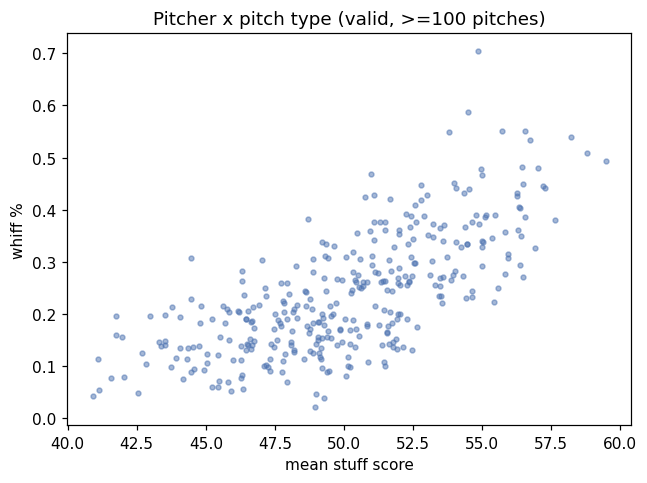

In [16]:
pitcher = (va.groupby('player_name')
             .agg(pitches=('stuff_score', 'size'), stuff=('stuff_score', 'mean'),
                  swings=('swing', 'sum'), whiffs=('whiff', 'sum'))
             .query('pitches >= 300'))
pitcher['whiff_pct'] = pitcher['whiffs'] / pitcher['swings']
print('투수 단위 (300구 이상) corr(stuff, whiff%) :',
      round(pitcher[['stuff', 'whiff_pct']].corr(method='spearman').iloc[0, 1], 3))
display(pitcher.sort_values('stuff', ascending=False).head(15).round(3))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pp_q['stuff'], pp_q['whiff_pct'], s=10, alpha=.5, color='#4C72B0')
ax.set(title='Pitcher x pitch type (valid, >=100 pitches)', xlabel='mean stuff score', ylabel='whiff %')
plt.tight_layout(); plt.savefig('outputs/stage4_stuff_vs_whiff.png'); plt.show()

## 5. 산출물 저장

In [17]:
joblib.dump(hit_model, 'models/stage1_hit_rf.joblib', compress=3)
joblib.dump(calib, 'models/stage2_gamma_beta.joblib')
joblib.dump(stuff_model, 'models/stage3_stuff_lgbm.joblib')
joblib.dump(scaler, 'models/stage4_stuff_scaler.joblib', compress=3)

cols = ['game_date', 'game_pk', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'pitch_type',
        'description', 'events', 'pred_hit_quality', 'stuff_score']
feat[cols].assign(pitch_type=feat['pitch_type'].astype(str)).to_parquet('outputs/stuff_scores_2025.parquet', index=False)
pp.to_csv('outputs/valid_pitcher_pitchtype_leaderboard.csv', index=False, encoding='utf-8-sig')
summary.to_csv('outputs/stage1_metrics.csv', encoding='utf-8-sig')
metrics3.to_csv('outputs/stage3_metrics.csv', encoding='utf-8-sig')
print('saved')

saved
